In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y

 A) Grafique combinaciones simples de armónicos esféricos:

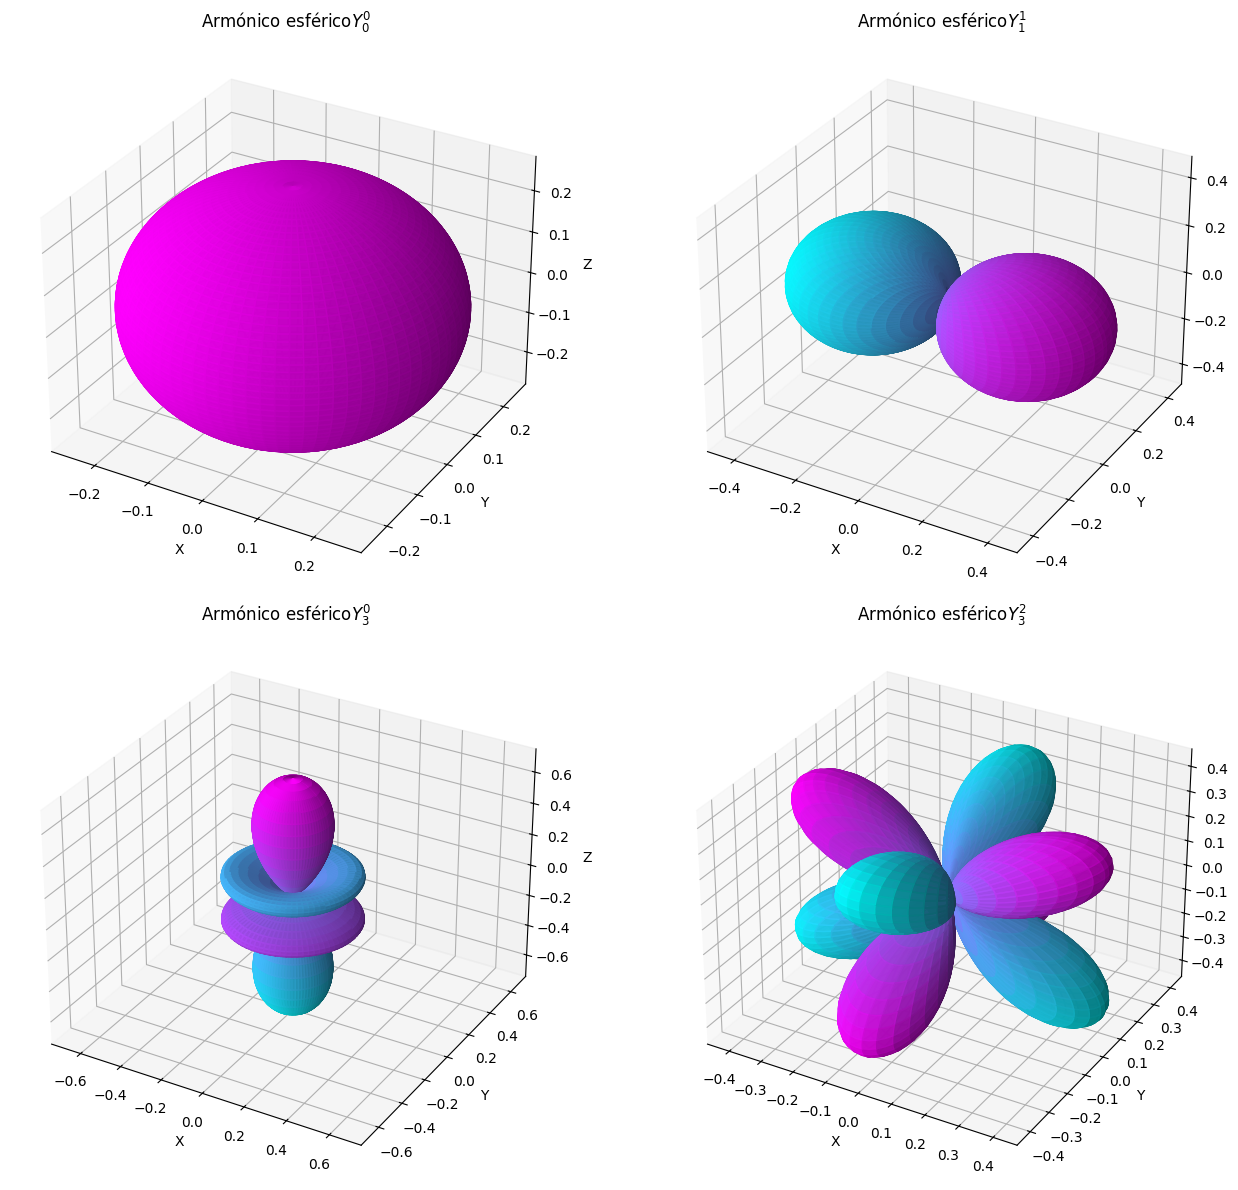

In [ ]:
plt.close('all')

# Definí las coordenadas esféricas
theta = np.linspace(0, np.pi, 120)
phi = np.linspace(0, 2*np.pi, 160)
theta, phi = np.meshgrid(theta, phi)

def calcular_armonico_real(l, m, theta, phi):
    m_abs = abs(m)
    Y_pos = sph_harm_y(l, m_abs, theta, phi)
    Y_neg = sph_harm_y(l, -m_abs, theta, phi)
# ℯ^{imϕ}=cos(mϕ)+isin(mϕ)
    if m == 0:
        Y_real = sph_harm_y(l, 0, theta, phi) #Si $m=0$, el armónico esférico ya es un número puramente real
    elif m > 0:
        Y_real = (1 / np.sqrt(2)) * (Y_neg + (-1)**m * Y_pos) #Realice la suma de los armónicos esféricos para cancelar las partes imaginarias entre sí y solo sobreviven las partes reales, que dependen de coseno, para normalizar la función
    else:
        Y_real = (1j / np.sqrt(2)) * (Y_neg - (-1)**m_abs * Y_pos) #Al restar las funciones, lo que se cancela es la parte real y sobrevive la parte imaginaria que luego multiplico por i (1j) para convertirlo en un número real.

#Del plano complejo al espacio 3D (cartesianas)

    Radio = np.abs(Y_real)
    x = Radio * np.sin(theta) * np.cos(phi)
    y = Radio * np.sin(theta) * np.sin(phi)
    z = Radio * np.cos(theta)

    return x, y, z, np.real(Y_real)


def graficar_en_subeje(ax, l, m):

    x, y, z, fase = calcular_armonico_real(l, m, theta, phi)
    fase_max = np.max(np.abs(fase))
    fase_norm = (fase / fase_max + 1) / 2 if fase_max > 0 else fase
    ax.plot_surface(x, y, z, facecolors=plt.cm.cool(fase_norm),
                    rstride=2, cstride=2, antialiased=True, alpha=0.9)

    ax.set_title("Armónico esférico" f'$Y^{m}_{{{l}}}$', fontsize=12)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    max_val = np.max([np.max(np.abs(x)), np.max(np.abs(y)), np.max(np.abs(z))])
    if max_val < 1e-5:
        max_val = 0.1

    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.set_zlim(-max_val, max_val)


fig = plt.figure(figsize=(14, 12))

# Gráfica 1: l=0, m=0
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
graficar_en_subeje(ax1, l=0, m=0)

# Gráfica 2:l=1, m=1
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
graficar_en_subeje(ax2, l=1, m=1)

# Gráfica 3: l=3, m=0
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
graficar_en_subeje(ax3, l=3, m=0)

# Gráfica 4: l=3, m=2
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
graficar_en_subeje(ax4, l=3, m=2)

plt.tight_layout()
plt.show()

B) Compare los patrones dominados por multipolos bajos y multipolos altos.


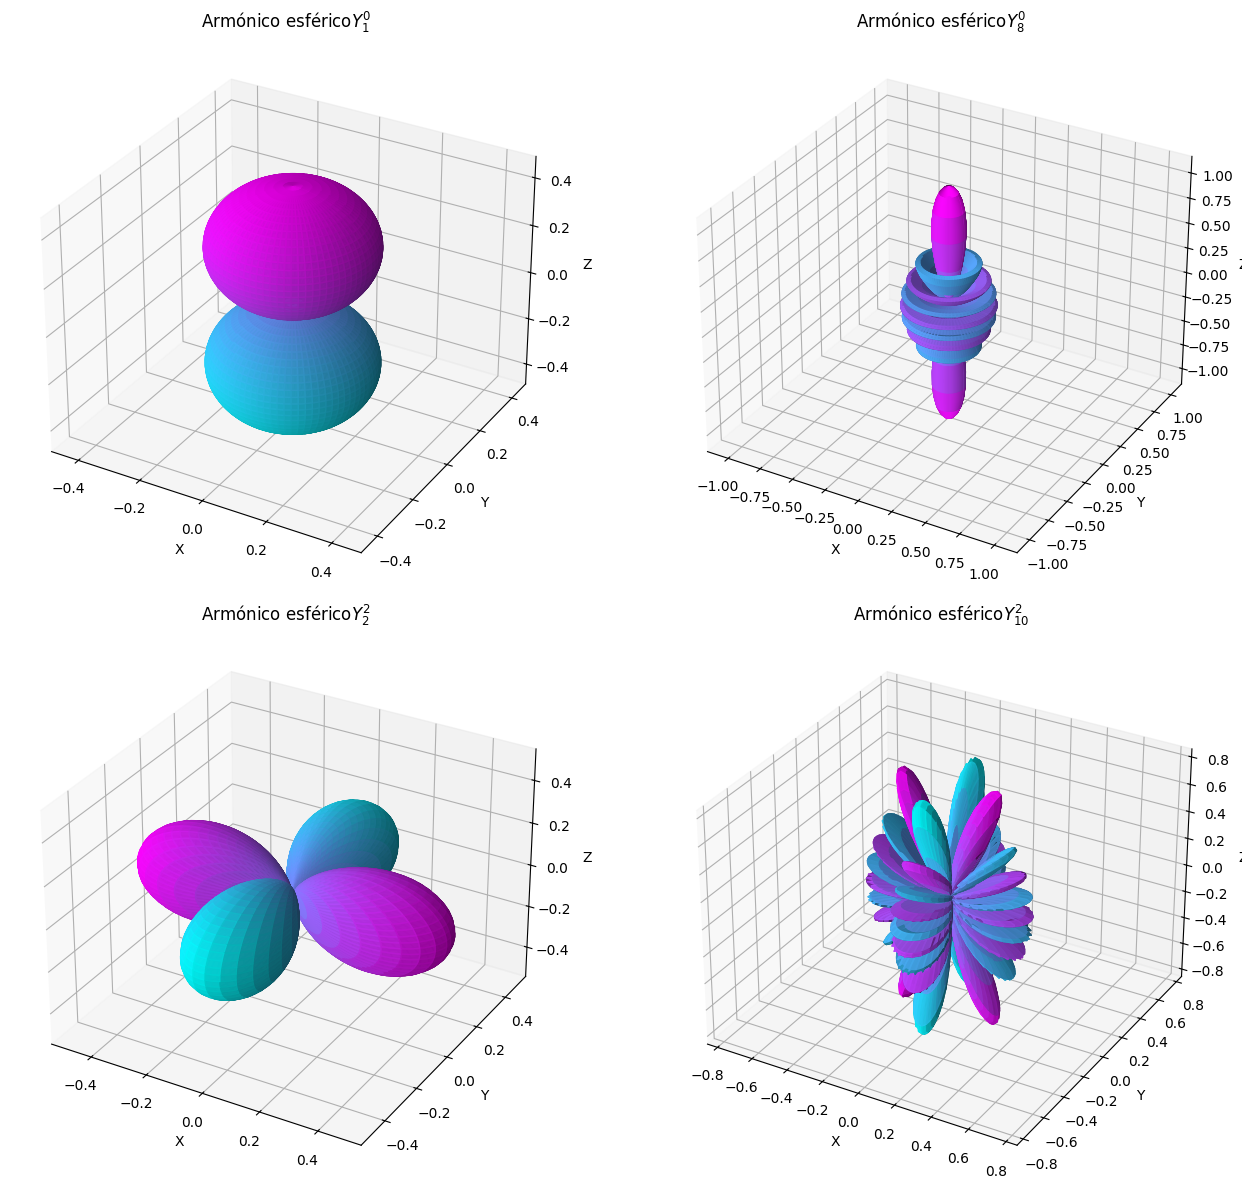

In [ ]:
fig = plt.figure(figsize=(14, 12))

# Gráfica 1: l=1, m=0
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
graficar_en_subeje(ax1, l=1, m=0)

# Gráfica 2:l=8, m=0
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
graficar_en_subeje(ax2, l=8, m=0)

# Gráfica 3: l=2, m=2
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
graficar_en_subeje(ax3, l=2, m=2)

# Gráfica 4: l=10, m=2
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
graficar_en_subeje(ax4, l=10, m=2)

plt.tight_layout()
plt.show()

Funciones de Neumann

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp

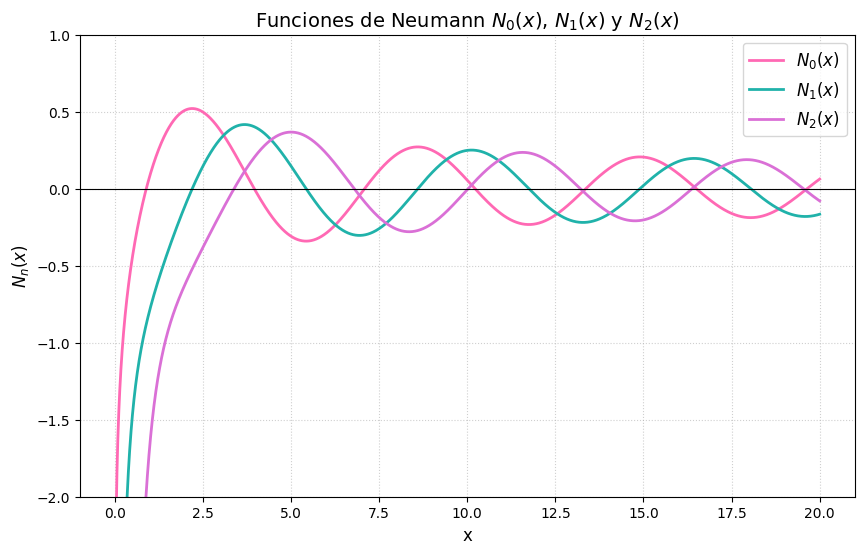

In [ ]:
x= np.linspace(0.01, 20, 5000)
n0=sp.yn(0,x)
n1=sp.yn(1,x)
n2=sp.yn(2,x)

plt.figure(figsize=(10,6))
plt.plot(x, n0, label='$N_0(x)$', color="hotpink", linewidth=2)
plt.plot(x, n1, label='$N_1(x)$', color="lightseagreen", linewidth=2)
plt.plot(x, n2, label='$N_2(x)$', color="orchid", linewidth=2)

plt.ylim(-2,1)
plt.axhline

plt.title('Funciones de Neumann $N_0(x)$, $N_1(x)$ y $N_2(x)$', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('$N_n(x)$', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()
